In [2]:
import os
import sys
import numpy as np
from itertools import product
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pandas as pd

import datastructure as D
import help_functions as H
import models as m

# Set paths, import modules, and load ratings and movie data.

In [3]:
# dataset_path = r'G:\My Drive\AIMS\AML@SCALE\projects\RECOMMENDER-SYSTEM\data\ml-1m\ml-25m'

# folder = 'files'

# path = r'G:\My Drive\AIMS\AML@SCALE\projects\RECOMMENDER-SYSTEM'

dataset_path = r'G:\My Drive\AIMS\AML@SCALE\projects\RECOMMENDER-SYSTEM\data\ml-25m'

folder = 'files_25m'

path = r'G:\My Drive\AIMS\AML@SCALE\projects\RECOMMENDER-SYSTEM'

In [4]:
import importlib
import datastructure

importlib.reload(datastructure)

D = datastructure

In [5]:
module_path = os.path.abspath(path)
sys.path.insert(0, module_path)

image_path = os.path.join(path, folder, 'plots')



D.load_ratings_data(path, dataset_path, folder)
D.load_movies_data(path, dataset_path, folder)

In [6]:
#specifying the fonts of all images
fontsize = 18
params = {
    'axes.labelsize': fontsize,
    'axes.titlesize': fontsize,
    'xtick.labelsize': fontsize,
    'ytick.labelsize': fontsize,
    'legend.fontsize' : fontsize
}
plt.rcParams.update(params)

# Rating distribution


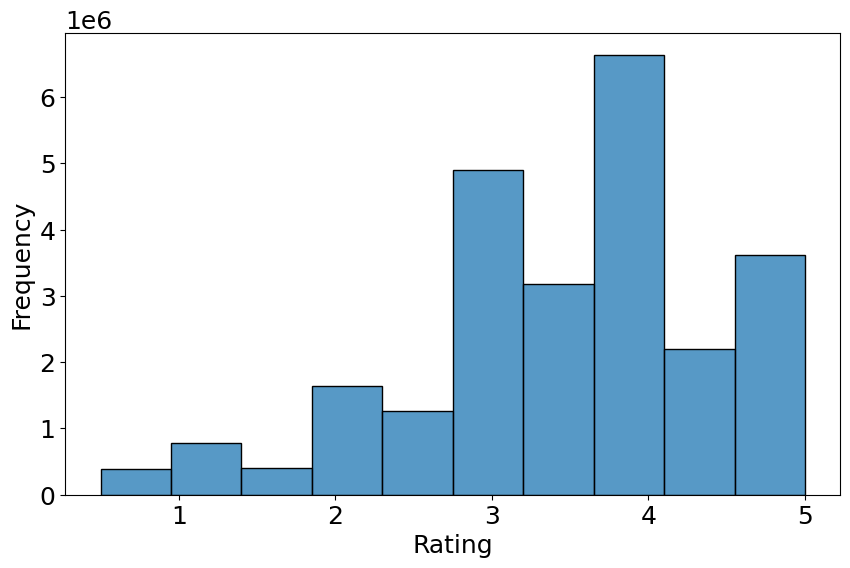

In [7]:
H.plot_rating_distribution(path, folder)

# Powerlaw distribution

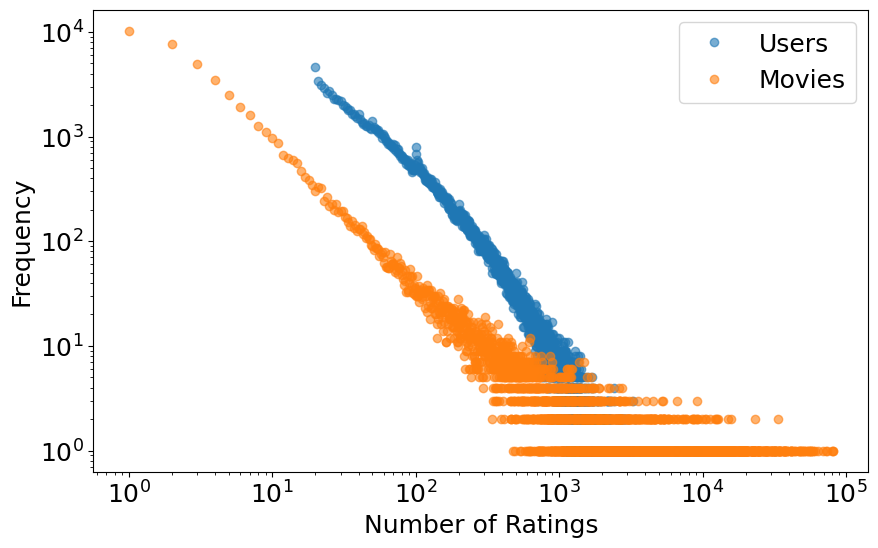

In [8]:
H.plot_powerlaw_distribution(path, folder)

# Splitting the data

In [9]:
D.train_test_split(path, folder, seed=0, test_size=0.2)

Train-test split completed and saved successfully.


In [24]:
#Load the model files
users_list_train = H.load_from_numpy(os.path.join(path, folder, 'split'), 'users_list_train')
users_indices_train = H.load_from_numpy(os.path.join(path, folder, 'split'), 'users_indices_train')
movies_list_train = H.load_from_numpy(os.path.join(path, folder, 'split'), 'movies_list_train')
movies_indices_train = H.load_from_numpy(os.path.join(path, folder, 'split'), 'movies_indices_train')
users_list_test = H.load_from_numpy(os.path.join(path, folder, 'split'), 'users_list_test')
users_indices_test = H.load_from_numpy(os.path.join(path, folder, 'split'), 'users_indices_test')

map_users_to_ids = H.load_from_pickle(os.path.join(path, folder,'preprocess'), 'map_users_to_ids')
map_movies_to_ids = H.load_from_pickle(os.path.join(path, folder,'preprocess'),'map_movies_to_ids')

# Biases-only model

## Grid search for best hyperparameters



In [11]:
# Define parameter ranges
lambda_values = [0.1, 0.07, 0.05, 0.01]
gamma_values = [0.01, 0.05, 0.005, 0.001]

# To store the best parameters and corresponding RMSE
best_params = {'lambda': None, 'gamma': None}
best_test_rmse = float('inf')

n_iterations = 10

# Loop through all combinations of lambda and gamma
for lamda, gamma in product(lambda_values, gamma_values):
    print(f"Testing combination: lambda={lamda}, gamma={gamma}")

    # Initialize variables for this parameter combination
    n_users, n_movies = len(map_users_to_ids), len(map_movies_to_ids)
    users_biases = np.zeros(n_users)
    movies_biases = np.zeros(n_movies)
    loss_history = []
    rmse_history = {'train': [], 'test': []}

    # Training loop
    with tqdm(range(n_iterations), unit='epochs') as tepochs:
        tepochs.set_description(f'Training (lambda={lamda}, gamma={gamma})')
        for _ in tepochs:
            # Update biases
            users_biases, movies_biases = m.compute_biases_update(
                users_list_train, movies_list_train, users_indices_train, movies_indices_train,
                users_biases, movies_biases, lamda, gamma
            )

            # Calculate loss and RMSE
            loss = m.calculate_loss(users_list_train, users_indices_train, users_biases, movies_biases, lamda, gamma)
            train_rmse, test_rmse = m.calculate_rmse(
                users_indices_train, users_list_train, users_indices_test, users_list_test,
                users_biases, movies_biases
            )

            # Store loss and RMSE history
            loss_history.append(loss)
            rmse_history['train'].append(train_rmse)
            rmse_history['test'].append(test_rmse)

            # Update progress bar
            tepochs.set_postfix(loss=loss_history[-1], rmse_train=rmse_history['train'][-1], rmse_test=rmse_history['test'][-1])

    # Evaluate and track the best parameter combination
    final_test_rmse = rmse_history['test'][-1]  # Final test RMSE for this combination
    if final_test_rmse < best_test_rmse:
        best_test_rmse = final_test_rmse
        best_params['lambda'] = lamda
        best_params['gamma'] = gamma

# Print the best parameters and corresponding RMSE
print(f"Best Parameters: lambda={best_params['lambda']}, gamma={best_params['gamma']}")
print(f"Lowest Test RMSE: {best_test_rmse}")


Testing combination: lambda=0.1, gamma=0.01


  0%|          | 0/10 [00:00<?, ?epochs/s]

Testing combination: lambda=0.1, gamma=0.05


  0%|          | 0/10 [00:00<?, ?epochs/s]

Testing combination: lambda=0.1, gamma=0.005


...

Testing combination: lambda=0.01, gamma=0.005


  0%|          | 0/10 [00:00<?, ?epochs/s]

Testing combination: lambda=0.01, gamma=0.001


  0%|          | 0/10 [00:00<?, ?epochs/s]

Best Parameters: lambda=0.05, gamma=0.01
Lowest Test RMSE: 0.8595996831604227


## Running the biases_only model with the best hyperparameters combination

In [12]:
# Hyperparameters
lamda = 0.05
gamma = 0.01
n_iterations = 30

# Initialize biases
n_users, n_movies = len(map_users_to_ids), len(map_movies_to_ids)
users_biases = np.zeros(n_users)
movies_biases = np.zeros(n_movies)

In [13]:
loss_history = []
rmse_history = {'train': [], 'test': []}

with tqdm(range(n_iterations), unit='epochs') as tepochs:
    tepochs.set_description('Training')
    for _ in tepochs:
        users_biases, movies_biases = m.compute_biases_update(users_list_train, movies_list_train, users_indices_train, movies_indices_train,
                    users_biases, movies_biases, lamda, gamma)
        loss = m.calculate_loss(users_list_train, users_indices_train, users_biases, movies_biases, lamda, gamma)
        train_rmse, test_rmse = m.calculate_rmse(users_indices_train, users_list_train, users_indices_test, users_list_test, users_biases, movies_biases)
        loss_history.append(loss)
        rmse_history['train'].append(train_rmse)
        rmse_history['test'].append(test_rmse)
        tepochs.set_postfix(loss=loss_history[-1], rmse_train=rmse_history['train'][-1], rmse_test=rmse_history['test'][-1])

os.makedirs(os.path.join(path, folder, 'model'), exist_ok=True)
H.save_to_numpy(os.path.join(path, folder, 'model'), users_biases, 'user_biases_bias')
H.save_to_numpy(os.path.join(path, folder, 'model'), movies_biases, 'movies_biases_bias')

  0%|          | 0/30 [00:00<?, ?epochs/s]

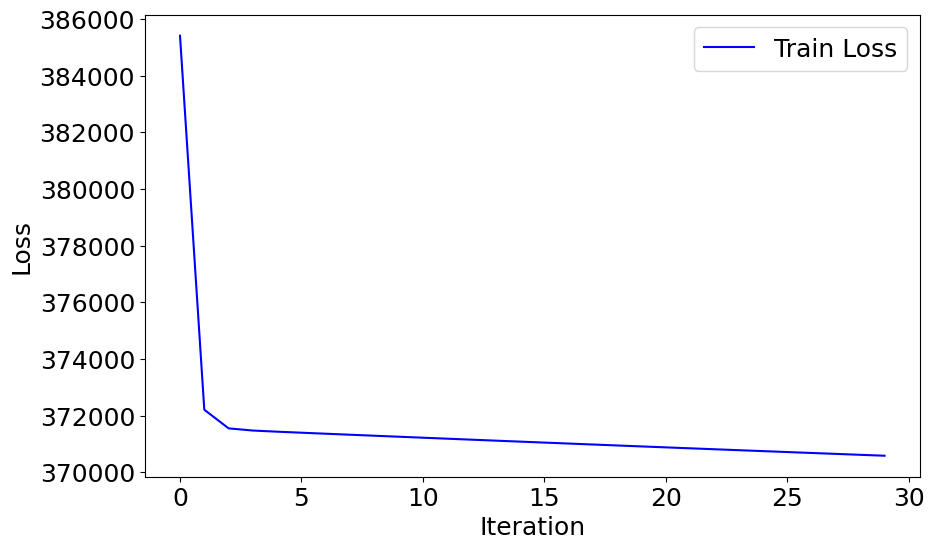

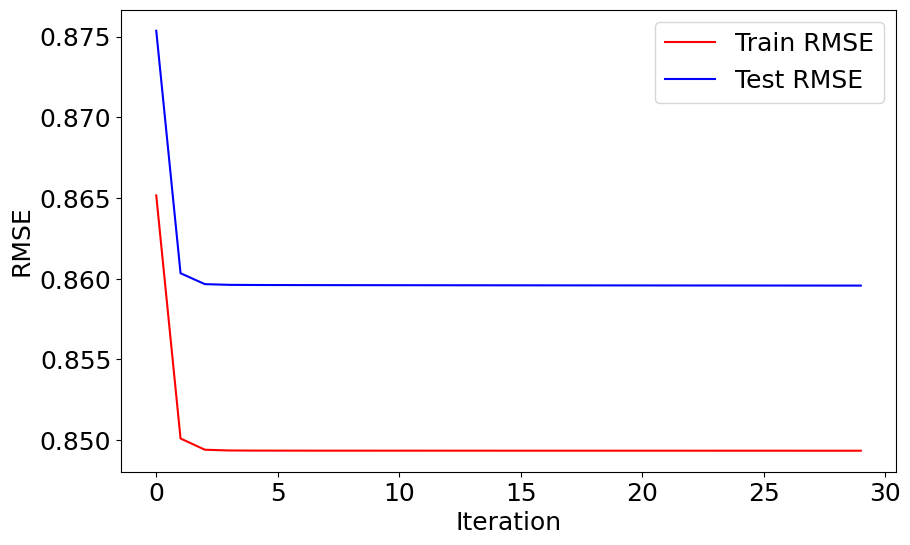

Plots saved in G:\My Drive\AIMS\AML@SCALE\projects\RECOMMENDER-SYSTEM\files_25m\plots


In [14]:
H.plot_loss_and_rmse(path, folder, loss_history, rmse_history, model_type='bias')

# Biases with factors model

## Grid search for best hyperparameters (set K = 2)


In [15]:
# Define hyperparameter ranges
lambda_values = [0.1, 0.07, 0.05, 0.01]
gamma_values = [0.01, 0.05, 0.005, 0.001]
tau_values = [1, 0.9, 0.7, 0.5]

# Fixed hyperparameters
n_iterations = 10
K = 2
SEED = 0
np.random.seed(SEED)

# Initialize placeholders for best parameters
best_lambda = None
best_gamma = None
best_tau = None
best_rmse = float('inf')

results = []

# Grid search over lambda, gamma, and tau
for lamda in lambda_values:
    for gamma in gamma_values:
        for tau in tau_values:
            print(f"Testing combination: lambda={lamda}, gamma={gamma}, tau={tau}")

            # Initialize biases and factors
            n_users, n_movies = len(map_users_to_ids), len(map_movies_to_ids)
            users_biases = np.zeros(n_users)
            movies_biases = np.zeros(n_movies)
            users_factors = np.random.normal(0, 1/np.sqrt(K), size=(n_users, K))
            movies_factors = np.random.normal(0, 1/np.sqrt(K), size=(n_movies, K))

            loss_history = []
            rmse_history = {'train': [], 'test': []}

            with tqdm(range(n_iterations), unit='epochs') as tepochs:
                tepochs.set_description(f"Training (lambda={lamda}, gamma={gamma}, tau={tau})")
                for _ in tepochs:
                    # Compute user and movie biases and factors
                    users_biases, users_factors = m.compute_user_biases_and_factors(
                        users_list_train, users_indices_train, users_biases,
                        users_factors, movies_factors, movies_biases, lamda, gamma, tau
                    )
                    movies_biases, movies_factors = m.compute_movie_biases_and_factors(
                        movies_list_train, movies_indices_train, users_biases,
                        users_factors, movies_factors, movies_biases, lamda, gamma, tau
                    )

                    # Calculate loss and RMSE
                    loss = m.calculate_loss_with_factors(
                        users_list_train, users_indices_train, users_biases, users_factors,
                        movies_biases, movies_factors, lamda, gamma, tau
                    )
                    train_rmse, test_rmse = m.calculate_rmse_with_factors(
                        users_indices_train, users_list_train, users_indices_test, users_list_test,
                        users_biases, users_factors, movies_biases, movies_factors
                    )

                    loss_history.append(loss)
                    rmse_history['train'].append(train_rmse)
                    rmse_history['test'].append(test_rmse)
                    tepochs.set_postfix(rmse_train=rmse_history['train'][-1], rmse_test=rmse_history['test'][-1])

            # Record final test RMSE
            final_test_rmse = rmse_history['test'][-1]
            results.append({'lambda': lamda, 'gamma': gamma, 'tau': tau, 'test_rmse': final_test_rmse})

            # Update best parameters if current combination is better
            if final_test_rmse < best_rmse:
                best_lambda = lamda
                best_gamma = gamma
                best_tau = tau
                best_rmse = final_test_rmse
                print(f"New best parameters: lambda={best_lambda}, gamma={best_gamma}, tau={best_tau}, test_rmse={best_rmse}")

# Output the best parameter combination
print(f"\nBest combination: lambda={best_lambda}, gamma={best_gamma}, tau={best_tau} with test_rmse={best_rmse}")

# Run the model with the best parameters
print(f"Running final model with lambda={best_lambda}, gamma={best_gamma}, tau={best_tau}")


Testing combination: lambda=0.1, gamma=0.01, tau=1


  0%|          | 0/10 [00:00<?, ?epochs/s]

New best parameters: lambda=0.1, gamma=0.01, tau=1, test_rmse=0.8184504763849225
Testing combination: lambda=0.1, gamma=0.01, tau=0.9


  0%|          | 0/10 [00:00<?, ?epochs/s]

Testing combination: lambda=0.1, gamma=0.01, tau=0.7


...

Testing combination: lambda=0.01, gamma=0.001, tau=0.7


  0%|          | 0/10 [00:00<?, ?epochs/s]

Testing combination: lambda=0.01, gamma=0.001, tau=0.5


  0%|          | 0/10 [00:00<?, ?epochs/s]


Best combination: lambda=0.1, gamma=0.05, tau=0.5 with test_rmse=0.8172071846301797
Running final model with lambda=0.1, gamma=0.05, tau=0.5


### Training the model with k=2 and its optimal hyperparameters

In [20]:
# Hyperparameters
lamda = 0.1
gamma = 0.05
tau = 0.5
n_iterations = 30
K = 2
SEED = 0

np.random.seed(SEED)

# Initialize biases
n_users, n_movies = len(map_users_to_ids), len(map_movies_to_ids)
users_biases = np.zeros(n_users)
movies_biases = np.zeros(n_movies)
users_factors = np.random.normal(0, 1/np.sqrt(K), size=(n_users, K))
movies_factors = np.random.normal(0, 1/np.sqrt(K), size=(n_movies, K))

In [21]:
loss_history = []
rmse_history = {'train': [], 'test': []}

with tqdm(range(n_iterations), unit='epochs') as tepochs:
    tepochs.set_description('Training')
    for _ in tepochs:
        user_biases, users_factors = m.compute_user_biases_and_factors(users_list_train, users_indices_train, users_biases,
                                                                        users_factors, movies_factors, movies_biases, lamda, gamma, tau)
        movie_biases, movies_factors = m.compute_movie_biases_and_factors(movies_list_train, movies_indices_train, users_biases,
                                                                        users_factors, movies_factors, movies_biases, lamda, gamma, tau)
        loss = m.calculate_loss_with_factors(users_list_train, users_indices_train, users_biases, users_factors,
                                 movies_biases, movies_factors, lamda, gamma, tau)
        train_rmse, test_rmse = m.calculate_rmse_with_factors(users_indices_train, users_list_train, users_indices_test, users_list_test, users_biases, users_factors,
                                   movies_biases, movies_factors)

        loss_history.append(loss)
        rmse_history['train'].append(train_rmse)
        rmse_history['test'].append(test_rmse)
        tepochs.set_postfix(rmse_train=rmse_history['train'][-1], rmse_test=rmse_history['test'][-1])

os.makedirs(os.path.join(path, folder, 'model'), exist_ok=True)
H.save_to_numpy(os.path.join(path, folder, 'model'), users_biases, 'users_biases')
H.save_to_numpy(os.path.join(path, folder, 'model'), users_factors, 'users_factors')
H.save_to_numpy(os.path.join(path, folder, 'model'), movies_biases, 'movies_biases')
H.save_to_numpy(os.path.join(path, folder, 'model'), movies_factors,'movies_factors')

  0%|          | 0/30 [00:00<?, ?epochs/s]

###  Loss and RMSE plots where k=2 and its optimal hyperparameters

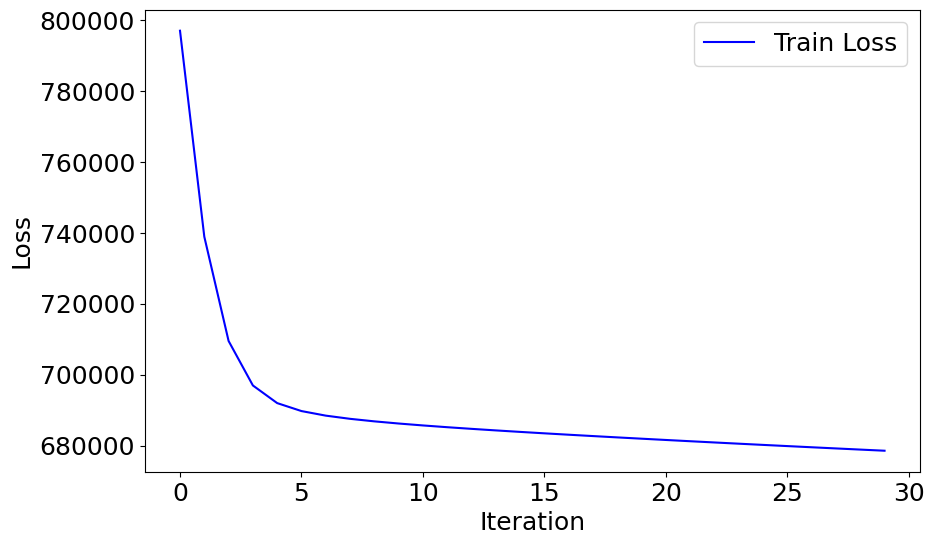

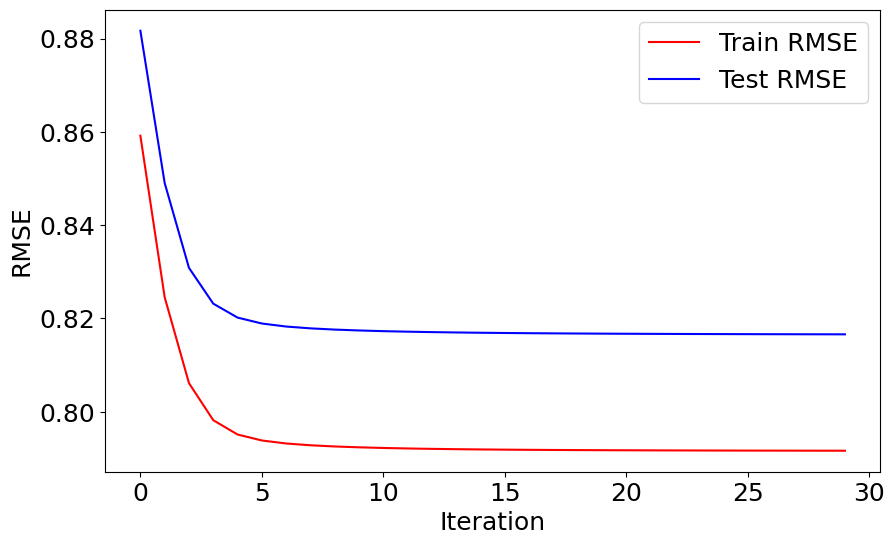

Plots saved in G:\My Drive\AIMS\AML@SCALE\projects\RECOMMENDER-SYSTEM\files_25m\plots


In [22]:
H.plot_loss_and_rmse(path, folder, loss_history, rmse_history, model_type='')

### 2D Embeddings for K = 2

In [26]:

# Load the movies metadata (movies.csv)
movies_df = H.load_from_pickle(os.path.join(path, folder, 'preprocess'), 'movies')
movie_factors = H.load_from_numpy(os.path.join(path, folder, 'model'), 'movies_factors')
# Ensure K = 2
# Select specific movies to display (e.g., movies with specific genres or themes)
# Here we manually choose some well-known movies based on their movieId
selected_movies = {
    1: "Toy Story (1995)",  # Example of an animation movie
    2: "Jumanji (1995)",    # Example of an adventure movie
    356: "Forrest Gump (1994)",  # Example of a drama
    318: "Shawshank Redemption (1994)",  # Example of a highly-rated drama
    296: "Pulp Fiction (1994)",  # Example of a crime movie
    593: "Silence of the Lambs (1991)",  # Example of a thriller
    2571: "Matrix (1999)",  # Example of sci-fi/action
    4993: "Lord of the Rings: Fellowship of the Ring (2001)",  # Example of fantasy
    5816: "Harry Potter and the Sorcerer's Stone (2001)",  # Example of fantasy/adventure
    1196: "Star Wars: A New Hope (1977)"  # Example of sci-fi/fantasy
}

# Extract embeddings for selected movies
selected_indices = []
selected_movie_titles = []

for movie_id, title in selected_movies.items():
    if movie_id in map_movies_to_ids:
        selected_indices.append(map_movies_to_ids[movie_id])
        selected_movie_titles.append(title)

selected_embeddings = movies_factors[selected_indices, :]
map_movies_to_ids = H.load_from_pickle(
    os.path.join(path, folder, 'preprocess'),
    'map_movies_to_ids'
)

selected_indices = [
    map_movies_to_ids[mid]
    for mid in selected_movie_ids
    if mid in map_movies_to_ids
]

selected_embeddings = movies_factors[selected_indices, :] # Extract embeddings for selected movies

# Create a scatter plot of the selected movies' 2D embeddings
plt.figure(figsize=(12, 8))

# Plot the embeddings of the selected movies
for i, title in enumerate(selected_movie_titles):
    plt.scatter(
        selected_embeddings[i, 0],  # Latent Dimension 1
        selected_embeddings[i, 1],  # Latent Dimension 2
        label=title,
        s=100,  # Marker size
        alpha=0.8
    )
    plt.text(
        selected_embeddings[i, 0] + 0.02,  # Offset for better readability
        selected_embeddings[i, 1] + 0.02,
        title,
        fontsize=13,
        alpha=0.7
    )

# Set the plot title and labels
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(alpha=0.3)
plt.savefig(image_path + '2D_embedding_K=2.pdf', format='pdf', dpi=3000)
plt.show()


NameError: name 'selected_movie_ids' is not defined

### Predictions for K = 2

In [ ]:
H.recommend_movies(path, folder, 1, 5, 10, lamda, gamma, tau)

Since you liked 'Toy Story (1995)', 
You may also like: 

1. Juno and Paycock (1930)
2. Sound of Music, The (1965)
3. Music of the Heart (1999)
4. Out of Africa (1985)
5. Meet Me in St. Louis (1944)
6. Sister Act (1992)
7. South Pacific (1958)
8. Steel Magnolias (1989)
9. Cinderella (1950)
10. Sense and Sensibility (1995)


In [ ]:
H.recommend_movies(path, folder, 2116, 5, 10, lamda, gamma, tau)

Since you liked 'Lord of the Rings, The (1978)', 
You may also like: 

1. Half Baked (1998)
2. Me, Myself and Irene (2000)
3. Dumb & Dumber (1994)
4. Happy Gilmore (1996)
5. Billy Madison (1995)
6. Austin Powers
7. Road Trip (2000)
8. Children of the Corn (1984)
9. From Dusk Till Dawn (1996)
10. Halloween 4


In [ ]:
H.recommend_movies(path, folder, 4993, 5, 10, lamda, gamma, tau)

KeyError: 4993

In [ ]:
H.recommend_movies(path, folder, 4896, 5, 10, lamda, gamma, tau)

KeyError: 4896

In [ ]:
H.recommend_movies(path, folder, 63992, 5, 10, lamda, gamma, tau)

Since you liked 'Twilight (2008)', 
You may also like: 

1. Twilight Saga: Breaking Dawn - Part 1, The (2011)
2. Twilight Saga: Breaking Dawn - Part 2, The (2012)
3. Twilight Saga: Eclipse, The (2010)
4. Twilight Saga: New Moon, The (2009)
5. Twilight (2008)
6. Princess Diaries 2: Royal Engagement, The (2004)
7. Maid in Manhattan (2002)
8. High School Musical (2006)
9. Wedding Planner, The (2001)
10. Runaway Bride (1999)


## Grid search for the optimal value of K

In [ ]:
# Best values from the previous grid search
best_lambda = 0.1
best_gamma = 0.05
best_tau = 0.5

# K values to test
k_values = [2, 4, 8, 16, 32]

# Store results for each K
k_results = []
n_iterations = 10
# Grid search over K
for k in k_values:
    print(f"Testing with K={k}")

    # Reinitialize biases and factors with the current K
    n_users, n_movies = len(map_users_to_ids), len(map_movies_to_ids)
    users_biases = np.zeros(n_users)
    movies_biases = np.zeros(n_movies)
    users_factors = np.random.normal(0, 1/np.sqrt(k), size=(n_users, k))
    movies_factors = np.random.normal(0, 1/np.sqrt(k), size=(n_movies, k))

    loss_history = []
    rmse_hihyperparametersstory = {'train': [], 'test': []}

    with tqdm(range(n_iterations), unit='epochs') as tepochs:
        tepochs.set_description(f"Training with K={k}")
        for _ in tepochs:
            # Compute user and movie biases and factors
            users_biases, users_factors = m.compute_user_biases_and_factors(
                users_list_train, users_indices_train, users_biases,
                users_factors, movies_factors, movies_biases, best_lambda, best_gamma, best_tau
            )
            movies_biases, movies_factors = m.compute_movie_biases_and_factors(
                movies_list_train, movies_indices_train, users_biases,
                users_factors, movies_factors, movies_biases, best_lambda, best_gamma, best_tau
            )

            # Calculate loss and RMSE
            loss = m.calculate_loss_with_factors(
                users_list_train, users_indices_train, users_biases, users_factors,
                movies_biases, movies_factors, best_lambda, best_gamma, best_tau
            )
            train_rmse, test_rmse = m.calculate_rmse_with_factors(
                users_indices_train, users_list_train, users_indices_test, users_list_test,
                users_biases, users_factors, movies_biases, movies_factors
            )

            loss_history.append(loss)
            rmse_history['train'].append(train_rmse)
            rmse_history['test'].append(test_rmse)
            tepochs.set_postfix(rmse_train=rmse_history['train'][-1], rmse_test=rmse_history['test'][-1])

    # Record final test RMSE for the current K
    final_test_rmse = rmse_history['test'][-1]
    k_results.append({'k': k, 'test_rmse': final_test_rmse})
    print(f"K={k}, Test RMSE={final_test_rmse}")

# Find the best K
best_k_result = min(k_results, key=lambda x: x['test_rmse'])
best_k = best_k_result['k']
best_k_rmse = best_k_result['test_rmse']

# Output the results
print("\nResults for all K values:")
for result in k_results:
    print(f"K={result['k']}, Test RMSE={result['test_rmse']}")

print(f"\nBest K: {best_k} with Test RMSE={best_k_rmse}")


Testing with K=2


  0%|          | 0/10 [00:00<?, ?epochs/s]

K=2, Test RMSE=0.8184942023282917
Testing with K=4


  0%|          | 0/10 [00:00<?, ?epochs/s]

K=4, Test RMSE=0.8021550265191215
Testing with K=8


...

K=8, Test RMSE=0.7892190188885125
Testing with K=16


  0%|          | 0/10 [00:00<?, ?epochs/s]

K=16, Test RMSE=0.7893247170937788
Testing with K=32


  0%|          | 0/10 [00:00<?, ?epochs/s]

K=32, Test RMSE=0.8150591496604616

Results for all K values:
K=2, Test RMSE=0.8184942023282917
K=4, Test RMSE=0.8021550265191215
K=8, Test RMSE=0.7892190188885125
K=16, Test RMSE=0.7893247170937788
K=32, Test RMSE=0.8150591496604616

Best K: 8 with Test RMSE=0.7892190188885125


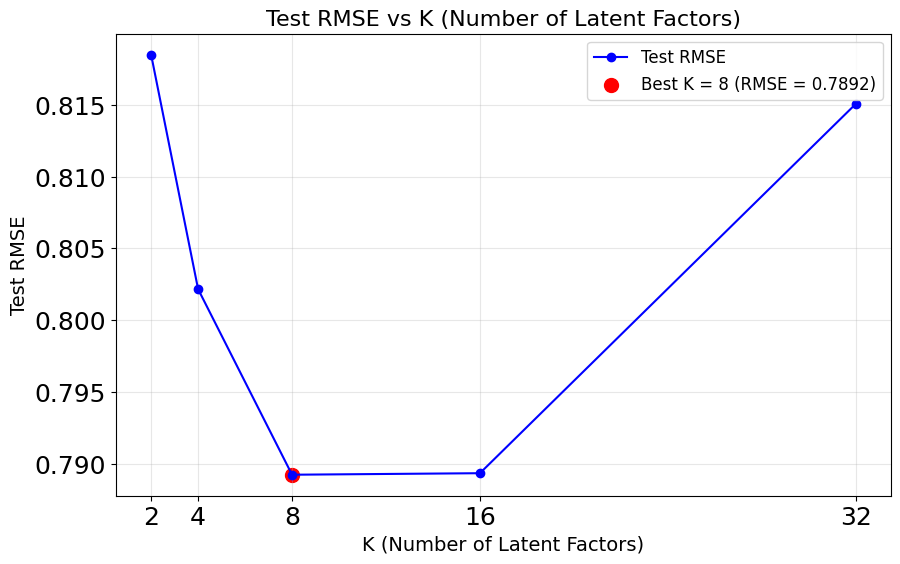

In [ ]:
import matplotlib.pyplot as plt

# Extract K values and RMSEs from the k_results obtained dynamically
k_values = [result['k'] for result in k_results]
rmse_values = [result['test_rmse'] for result in k_results]

# Plot K vs RMSE
plt.figure(figsize=(10, 6))
plt.plot(k_values, rmse_values, marker='o', linestyle='-', color='b', label='Test RMSE')

# Add labels, title, and grid
plt.title("Test RMSE vs K (Number of Latent Factors)", fontsize=16)
plt.xlabel("K (Number of Latent Factors)", fontsize=14)
plt.ylabel("Test RMSE", fontsize=14)
plt.xticks(k_values)  # Ensure all K values are shown on the x-axis
plt.grid(alpha=0.3)
plt.legend(fontsize=12)

# Annotate the best K
best_k = k_values[rmse_values.index(min(rmse_values))]
best_rmse = min(rmse_values)
plt.scatter(best_k, best_rmse, color='r', s=100, label=f"Best K = {best_k} (RMSE = {best_rmse:.4f})")
plt.legend(fontsize=12)

# Show the plot
plt.show()


## Using the optimal K= 8, to find the best Hyperparameters

In [ ]:
import numpy as np
from tqdm import tqdm
import os

# Optimal hyperparameters grid search
lambda_values = [0.1, 0.07, 0.05, 0.01]
gamma_values = [0.01, 0.05, 0.005, 0.001]
tau_values = [1, 0.9, 0.7, 0.5]

# Fixed hyperparameters
n_iterations = 5
K = 8
SEED = 0
np.random.seed(SEED)

# Initialize placeholders for best parameters
best_lambda = None
best_gamma = None
best_tau = None
best_rmse = float('inf')  # Initialize with a very high RMSE

# Store results for analysis
results = []

# Grid search over lambda, gamma, and tau
for lamda in lambda_values:
    for gamma in gamma_values:
        for tau in tau_values:
            print(f"Testing combination: lambda={lamda}, gamma={gamma}, tau={tau}")

            # Initialize biases and factors
            n_users, n_movies = len(map_users_to_ids), len(map_movies_to_ids)
            users_biases = np.zeros(n_users)
            movies_biases = np.zeros(n_movies)
            users_factors = np.random.normal(0, 1/np.sqrt(K), size=(n_users, K))
            movies_factors = np.random.normal(0, 1/np.sqrt(K), size=(n_movies, K))

            loss_history = []
            rmse_history = {'train': [], 'test': []}

            with tqdm(range(n_iterations), unit='epochs') as tepochs:
                tepochs.set_description(f"Training (lambda={lamda}, gamma={gamma}, tau={tau})")
                for _ in tepochs:
                    # Compute user and movie biases and factors
                    users_biases, users_factors = m.compute_user_biases_and_factors(
                        users_list_train, users_indices_train, users_biases,
                        users_factors, movies_factors, movies_biases, lamda, gamma, tau
                    )
                    movies_biases, movies_factors = m.compute_movie_biases_and_factors(
                        movies_list_train, movies_indices_train, users_biases,
                        users_factors, movies_factors, movies_biases, lamda, gamma, tau
                    )

                    # Calculate loss and RMSE
                    loss = m.calculate_loss_with_factors(
                        users_list_train, users_indices_train, users_biases, users_factors,
                        movies_biases, movies_factors, lamda, gamma, tau
                    )
                    train_rmse, test_rmse = m.calculate_rmse_with_factors(
                        users_indices_train, users_list_train, users_indices_test, users_list_test,
                        users_biases, users_factors, movies_biases, movies_factors
                    )

                    loss_history.append(loss)
                    rmse_history['train'].append(train_rmse)
                    rmse_history['test'].append(test_rmse)
                    tepochs.set_postfix(rmse_train=rmse_history['train'][-1], rmse_test=rmse_history['test'][-1])

            # Record final test RMSE
            final_test_rmse = rmse_history['test'][-1]
            results.append({'lambda': lamda, 'gamma': gamma, 'tau': tau, 'test_rmse': final_test_rmse})

            # Update best parameters if current combination is better
            if final_test_rmse < best_rmse:
                best_lambda = lamda
                best_gamma = gamma
                best_tau = tau
                best_rmse = final_test_rmse
                print(f"New best parameters: lambda={best_lambda}, gamma={best_gamma}, tau={best_tau}, test_rmse={best_rmse}")

# Output the best parameter combination
print(f"\nBest combination: lambda={best_lambda}, gamma={best_gamma}, tau={best_tau} with test_rmse={best_rmse}")

# Run the model with the best parameters
print(f"Running final model with lambda={best_lambda}, gamma={best_gamma}, tau={best_tau}")


Testing combination: lambda=0.1, gamma=0.01, tau=1


Training (lambda=0.1, gamma=0.01, tau=1): 100%|██████████| 5/5 [02:18<00:00, 27.61s/epochs, rmse_test=0.795, rmse_train=0.738]


New best parameters: lambda=0.1, gamma=0.01, tau=1, test_rmse=0.7952048445253403
Testing combination: lambda=0.1, gamma=0.01, tau=0.9


Training (lambda=0.1, gamma=0.01, tau=0.9): 100%|██████████| 5/5 [02:19<00:00, 27.90s/epochs, rmse_test=0.794, rmse_train=0.736]


New best parameters: lambda=0.1, gamma=0.01, tau=0.9, test_rmse=0.7939261833035927
Testing combination: lambda=0.1, gamma=0.01, tau=0.7


...

Testing combination: lambda=0.01, gamma=0.001, tau=0.7


Training (lambda=0.01, gamma=0.001, tau=0.7): 100%|██████████| 5/5 [02:09<00:00, 25.91s/epochs, rmse_test=0.806, rmse_train=0.774]


Testing combination: lambda=0.01, gamma=0.001, tau=0.5


Training (lambda=0.01, gamma=0.001, tau=0.5): 100%|██████████| 5/5 [02:11<00:00, 26.38s/epochs, rmse_test=0.801, rmse_train=0.763]


Best combination: lambda=0.05, gamma=0.05, tau=0.7 with test_rmse=0.791923500261414
Running final model with lambda=0.05, gamma=0.05, tau=0.7


# Plotting the best parameters

In [ ]:
# Hyperparameters
lamda = 0.05
gamma = 0.05
tau = 0.7
n_iterations = 20
K = 8
SEED = 0

np.random.seed(SEED)

# Initialize biases
n_users, n_movies = len(map_users_to_ids), len(map_movies_to_ids)
users_biases = np.zeros(n_users)
movies_biases = np.zeros(n_movies)
users_factors = np.random.normal(0, 1/np.sqrt(K), size=(n_users, K))
movies_factors = np.random.normal(0, 1/np.sqrt(K), size=(n_movies, K))

In [ ]:
loss_history = []
rmse_history = {'train': [], 'test': []}

with tqdm(range(n_iterations), unit='epochs') as tepochs:
    tepochs.set_description('Training')
    for _ in tepochs:
        user_biases, users_factors = m.compute_user_biases_and_factors(users_list_train, users_indices_train, users_biases,
                                                                        users_factors, movies_factors, movies_biases, lamda, gamma, tau)
        movie_biases, movies_factors = m.compute_movie_biases_and_factors(movies_list_train, movies_indices_train, users_biases,
                                                                        users_factors, movies_factors, movies_biases, lamda, gamma, tau)
        loss = m.calculate_loss_with_factors(users_list_train, users_indices_train, users_biases, users_factors,
                                 movies_biases, movies_factors, lamda, gamma, tau)
        train_rmse, test_rmse = m.calculate_rmse_with_factors(users_indices_train, users_list_train, users_indices_test, users_list_test, users_biases, users_factors,
                                   movies_biases, movies_factors)

        loss_history.append(loss)
        rmse_history['train'].append(train_rmse)
        rmse_history['test'].append(test_rmse)
        tepochs.set_postfix(rmse_train=rmse_history['train'][-1], rmse_test=rmse_history['test'][-1])

os.makedirs(os.path.join(path, folder, 'model'), exist_ok=True)
H.save_to_numpy(os.path.join(path, folder, 'model'), users_biases, 'users_biases')
H.save_to_numpy(os.path.join(path, folder, 'model'), users_factors, 'users_factors')
H.save_to_numpy(os.path.join(path, folder, 'model'), movies_biases, 'movies_biases')
H.save_to_numpy(os.path.join(path, folder, 'model'), movies_factors,'movies_factors')

Training: 100%|██████████| 20/20 [08:44<00:00, 26.22s/epochs, rmse_test=0.786, rmse_train=0.733]


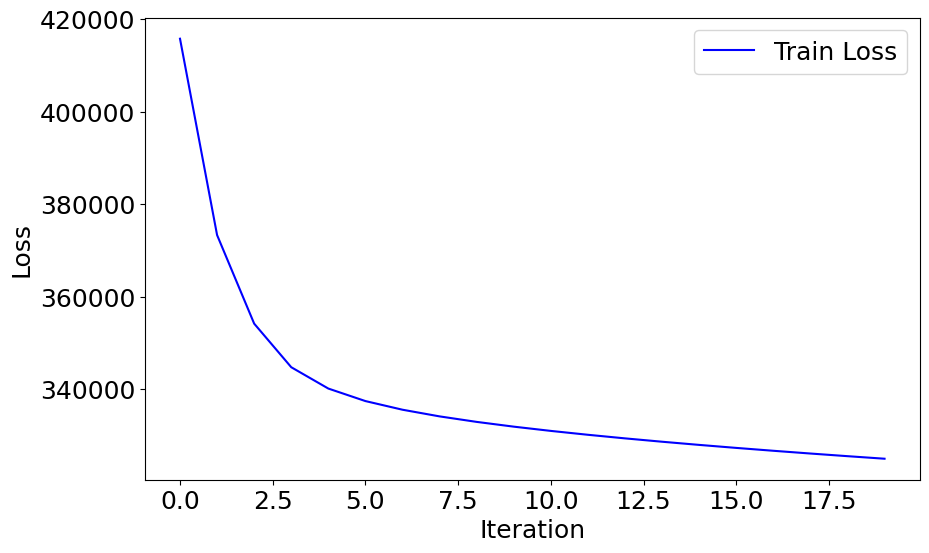

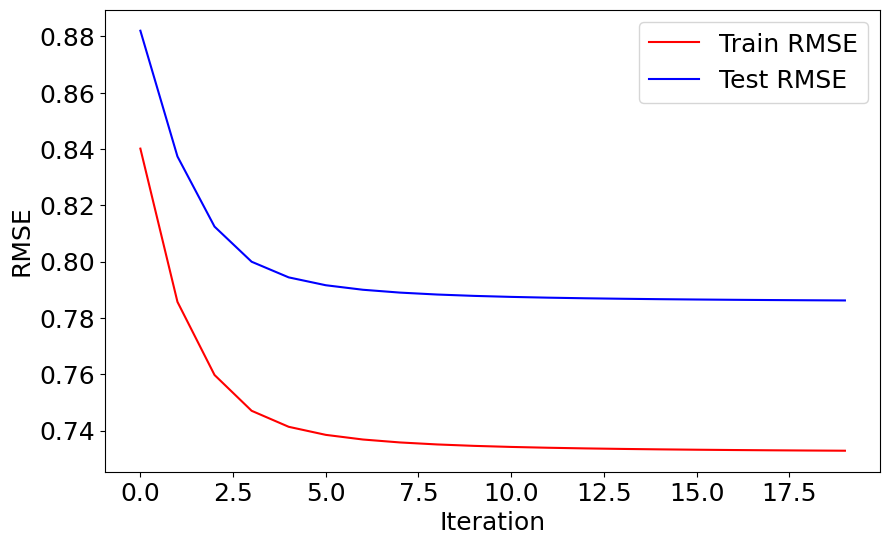

Plots saved in /content/drive/MyDrive/AIMS/AML@SCALE/AML@Scale/files/plots


In [ ]:
H.plot_loss_and_rmse(path, folder, loss_history, rmse_history, model_type='')

## 2D Embeddings for K = 8

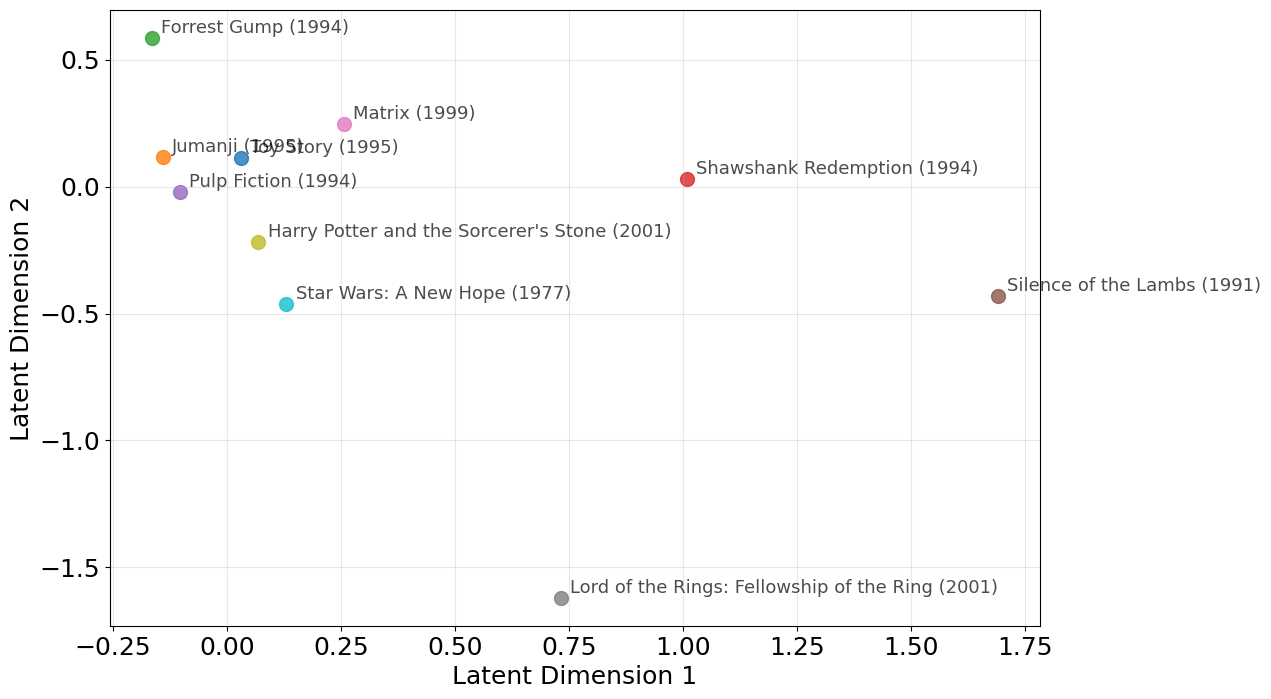

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the movies metadata (movies.csv)
movies_df = H.load_from_pickle(os.path.join(path, folder, 'preprocess'), 'movies')
movie_factors = H.load_from_numpy(os.path.join(path, folder, 'model'), 'movies_factors')
# Ensure K = 8

selected_movies = {
    1: "Toy Story (1995)",  # Example of an animation movie
    2: "Jumanji (1995)",    # Example of an adventure movie
    356: "Forrest Gump (1994)",  # Example of a drama
    318: "Shawshank Redemption (1994)",  # Example of a highly-rated drama
    296: "Pulp Fiction (1994)",  # Example of a crime movie
    593: "Silence of the Lambs (1991)",  # Example of a thriller
    2571: "Matrix (1999)",  # Example of sci-fi/action
    4993: "Lord of the Rings: Fellowship of the Ring (2001)",  # Example of fantasy
    5816: "Harry Potter and the Sorcerer's Stone (2001)",  # Example of fantasy/adventure
    1196: "Star Wars: A New Hope (1977)"  # Example of sci-fi/fantasy
}

# Extract embeddings for selected movies
selected_movie_ids = list(selected_movies.keys())
selected_movie_titles = list(selected_movies.values())
selected_embeddings = movies_factors[selected_movie_ids, :]  # Extract embeddings for selected movies

# Create a scatter plot of the selected movies' 2D embeddings
plt.figure(figsize=(12, 8))

# Plot the embeddings of the selected movies
for i, title in enumerate(selected_movie_titles):
    plt.scatter(
        selected_embeddings[i, 0],  # Latent Dimension 1
        selected_embeddings[i, 1],  # Latent Dimension 2
        label=title,
        s=100,  # Marker size
        alpha=0.8
    )
    plt.text(
        selected_embeddings[i, 0] + 0.02,  # Offset for better readability
        selected_embeddings[i, 1] + 0.02,
        title,
        fontsize=13,
        alpha=0.7
    )

# Set the plot title and labels
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(alpha=0.3)
plt.savefig(image_path + '2D_embedding_K=4.pdf', format='pdf', dpi=3000)
plt.show()


## Predictions for K = 8

In [ ]:
H.recommend_movies(path, folder, 1, 5, 10, lamda, gamma, tau)

Since you liked 'Toy Story (1995)', 
You may also like: 

1. Beauty and the Beast (1991)
2. Toy Story 2 (1999)
3. Toy Story (1995)
4. Babe (1995)
5. Toy Story 3 (2010)
6. Aladdin (1992)
7. Little Mermaid, The (1989)
8. Spider-Man 2 (2004)
9. Finding Nemo (2003)
10. Incredibles, The (2004)


In [ ]:
H.recommend_movies(path, folder, 4993, 5, 10, lamda, gamma, tau)

Since you liked 'Lord of the Rings: The Fellowship of the Ring, The (2001)', 
You may also like: 

1. Lord of the Rings: The Return of the King, The (2003)
2. Lord of the Rings: The Fellowship of the Ring, The (2001)
3. Lord of the Rings: The Two Towers, The (2002)
4. Star Wars: Episode III - Revenge of the Sith (2005)
5. Star Wars: Episode II - Attack of the Clones (2002)
6. Star Wars: Episode VI - Return of the Jedi (1983)
7. Star Wars: Episode I - The Phantom Menace (1999)
8. Hobbit: An Unexpected Journey, The (2012)
9. Hobbit: The Desolation of Smaug, The (2013)
10. Star Wars: Episode V - The Empire Strikes Back (1980)


In [ ]:
H.recommend_movies(path, folder, 4896, 5, 10, lamda, gamma, tau)

Since you liked 'Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)', 
You may also like: 

1. Harry Potter and the Deathly Hallows: Part 2 (2011)
2. Harry Potter and the Deathly Hallows: Part 1 (2010)
3. Lord of the Rings: The Return of the King, The (2003)
4. Lord of the Rings: The Fellowship of the Ring, The (2001)
5. Harry Potter and the Half-Blood Prince (2009)
6. Harry Potter and the Goblet of Fire (2005)
7. Harry Potter and the Order of the Phoenix (2007)
8. Lord of the Rings: The Two Towers, The (2002)
9. Harry Potter and the Prisoner of Azkaban (2004)
10. Harry Potter and the Chamber of Secrets (2002)


In [ ]:
H.recommend_movies(path, folder, 63992, 5, 10, lamda, gamma, tau)

Since you liked 'Twilight (2008)', 
You may also like: 

1. Twilight (2008)
2. Titanic (1997)
3. Twilight Saga: Eclipse, The (2010)
4. Twilight Saga: New Moon, The (2009)
5. Twilight Saga: Breaking Dawn - Part 1, The (2011)
6. Twilight Saga: Breaking Dawn - Part 2, The (2012)
7. Blair Witch Project, The (1999)
8. The Hunger Games: Catching Fire (2013)
9. The Hunger Games: Mockingjay - Part 1 (2014)
10. The Hunger Games (2012)
